# Séance 3 : POO Avancée — Structures Algébriques
## Polynômes et Matrices en Python

**M1 MAFI — Université d'Antananarivo — 2026–2027**

---

### Objectifs
- Maîtriser la POO avancée : classes abstraites, héritage, surcharge d'opérateurs.
- Implémenter la classe `Polynome` (anneau $\mathbb{K}[X]$) avec Horner, dérivée, PGCD.
- Implémenter la classe `Matrice` avec élimination de Gauss–Jordan.
- Introduction légère à **Lean 4** : formalisation de propriétés élémentaires.
- Mesurer et comparer les complexités $\mathcal{O}(n)$, $\mathcal{O}(n^2)$, $\mathcal{O}(n^3)$.

---

### Ressources
- Cormen et al., *Introduction to Algorithms*, 4e éd., MIT Press, 2022 — ch. 2 (Horner), ch. 30 (FFT).
- Strang, *Computational Science and Engineering*, Wellesley-Cambridge, 2007 — ch. 1–3 (Gauss).
- Trefethen & Bau, *Numerical Linear Algebra*, SIAM, 1997 — Lecture 20.
- Avigad et al., *Mathematics in Lean*, https://leanprover-community.github.io/mathematics_in_lean/ — §8.

---
**Rappel** : l'usage des assistants IA est autorisé pour déboguer, mais vous devez comprendre et documenter chaque ligne de code.

## Partie 0 — Environnement

In [1]:
import timeit
import random
import math
import copy
import matplotlib.pyplot as plt
from abc import ABC, abstractmethod

%matplotlib inline
print("Environnement prêt.")

Environnement prêt.


---
## Partie 1 — POO Avancée : Interface Algébrique

### 1.1 Classe abstraite `StructureAlgebrique`

Une **classe abstraite** (module `abc`) définit une interface que toute sous-classe doit respecter.  
Ici, on modélise un **anneau** : addition, multiplication, et élément neutre nul.

> **Référence** : Python docs, `abc` — https://docs.python.org/3/library/abc.html

In [2]:
class StructureAlgebrique(ABC):
    """Interface abstraite d'un anneau (addition + multiplication)."""

    @abstractmethod
    def __add__(self, other):
        """Addition dans la structure."""
        pass

    @abstractmethod
    def __mul__(self, other):
        """Multiplication dans la structure."""
        pass

    @property
    @abstractmethod
    def zero(self):
        """Élément neutre pour l'addition."""
        pass

    @abstractmethod
    def __eq__(self, other):
        pass

    def __ne__(self, other):
        return not self.__eq__(other)

# Test : on ne peut pas instancier une classe abstraite
try:
    s = StructureAlgebrique()
except TypeError as e:
    print(f"Erreur attendue : {e}")

Erreur attendue : Can't instantiate abstract class StructureAlgebrique without an implementation for abstract methods '__add__', '__eq__', '__mul__', 'zero'


### 1.2 Exemple : héritage et polymorphisme

**Exercice guidé** : compléter la classe `Entier` ci-dessous qui hérite de `StructureAlgebrique`.  
Elle sert d'illustration avant d'implémenter `Polynome`.

In [3]:
class Entier(StructureAlgebrique):
    """Entier comme anneau (illustration du polymorphisme)."""

    def __init__(self, valeur):
        self.val = int(valeur)

    def __add__(self, other):
        # TODO : retourner Entier(self.val + other.val)
        return Entier(self.val + other.val)

    def __mul__(self, other):
        # TODO : retourner Entier(self.val * other.val)
        return Entier(self.val * other.val)
  

    @property
    def zero(self):
        return Entier(0)

    def __eq__(self, other):
        if isinstance(other, Entier):
            return self.val == other.val
        return self.val == other

    def __repr__(self):
        return f"Entier({self.val})"

# Tests automatiques (décommentez après implémentation)
a, b = Entier(3), Entier(5)
assert (a + b) == Entier(8), "Addition incorrecte"
assert (a * b) == Entier(15), "Multiplication incorrecte"
print("Tests Entier OK")

Tests Entier OK


---
## Partie 2 — Classe `Polynome`

Un polynôme $P = a_0 + a_1 X + \cdots + a_n X^n \in \mathbb{K}[X]$ est représenté par la liste  
`coeffs = [a_0, a_1, ..., a_n]` (degré croissant), avec $a_n \neq 0$.

### 2.1 Initialisation et affichage

In [4]:
class Polynome(StructureAlgebrique):
    """
    Représentation d'un polynôme à coefficients réels.
    coeffs[i] est le coefficient de X^i.
    """

    def __init__(self, coeffs):
        """coeffs : liste/tuple de coefficients (degré croissant)."""
        self.coeffs = list(coeffs)
        self._normaliser()

    def _normaliser(self):
        """Supprime les zéros dominants."""
        while len(self.coeffs) > 1 and self.coeffs[-1] == 0:
            self.coeffs.pop()

    # Ajoutez ici les méthodes d'addition, multiplication, évaluation, etc.
    def __add__(self, other):
        """Addition de polynômes."""
        max_deg = max(self.degre, other.degre)
        result_coeffs = [self[i] + other[i] for i in range(max_deg + 1)]
        return Polynome(result_coeffs)
    
    def __mul__(self, other):
        """Multiplication de polynômes (méthode naïve)."""
        result_coeffs = [0] * (self.degre + other.degre + 1)
        for i in range(self.degre + 1):
            for j in range(other.degre + 1):
                result_coeffs[i + j] += self[i] * other[j]
        return Polynome(result_coeffs)
    
    def evaluer(self, x):
        """Évalue le polynôme en x."""
        result = 0
        for i, coeff in enumerate(self.coeffs):
            result += coeff * (x ** i)
        return result

    @property
    def degre(self):
        """Degré du polynôme (-1 pour le polynôme nul)."""
        if self.coeffs == [0]:
            return -1
        return len(self.coeffs) - 1

    @property
    def zero(self):
        return Polynome([0])

    def __getitem__(self, i):
        """Coefficient de X^i."""
        return self.coeffs[i] if 0 <= i < len(self.coeffs) else 0

    def __eq__(self, other):
        if isinstance(other, (int, float)):
            return self.coeffs == [other]
        if isinstance(other, Polynome):
            return self.coeffs == other.coeffs
        return NotImplemented

    def __repr__(self):
        return f"Polynome({self.coeffs})"

    def __str__(self):
        if self.degre == -1:
            return "0"
        termes = []
        for i, c in enumerate(self.coeffs):
            if c == 0:
                continue
            if i == 0:
                termes.append(str(c))
            elif i == 1:
                termes.append(f"({c})*X" if c != 1 else "X")
            else:
                termes.append(f"({c})*X^{i}" if c != 1 else f"X^{i}")
        return " + ".join(reversed(termes)) if termes else "0"

    def __call__(self, x):
        """Permet d'écrire P(x) directement."""
        return self.evaluer(x)

# Test rapide
P = Polynome([1, -2, 0, 3])   # 1 - 2X + 3X^3
print(f"P = {P}")
print(f"deg(P) = {P.degre}")
print(f"P[0] = {P[0]}, P[3] = {P[3]}")

P = (3)*X^3 + (-2)*X + 1
deg(P) = 3
P[0] = 1, P[3] = 3


### 2.2 Opérations arithmétiques (à compléter)

**Rappel mathématique** :
$$P + Q = \sum_{k=0}^{\max(m,n)} (a_k + b_k) X^k \qquad P \cdot Q = \sum_{k=0}^{m+n}\left(\sum_{i+j=k} a_i b_j\right) X^k$$

In [5]:
def polynome_add(self, other):
    """
    Addition de deux polynômes.
    Complexité : O(max(deg P, deg Q)).
    """
    # BUG CORRIGÉ : il fallait max(self.degre, other.degre), pas deux fois self.degre.
    # L'ancienne version tronquait le résultat au degré de self et cassait
    # silencieusement toute addition où other est de degré plus grand
    # (voir Exercice 2 : interpolation de Lagrange, qui donnait 0).
    n = max(self.degre, other.degre)
    result_coeffs = [self[i] + other[i] for i in range(n + 1)]
    return Polynome(result_coeffs)

def polynome_neg(self):
    """Opposé d'un polynôme."""
    return Polynome([-c for c in self.coeffs])

def polynome_sub(self, other):
    """Soustraction : P - Q = P + (-Q)."""
    return self.__add__(other.__neg__())

def polynome_mul(self, other):
    """
    Multiplication naïve de deux polynômes.
    Complexité : O(deg(P) * deg(Q)).
    """
    if isinstance(other, (int, float)):  #vérifier si other (int ou float) puis à multiplier tous les coefficients du polynôme par other.
        return Polynome([c * other for c in self.coeffs])
    #sinon(liste des coeffs)
    new_coeffs = [0] * (self.degre + other.degre + 1)
    for i in range(self.degre + 1):
        for j in range(other.degre + 1):
            new_coeffs[i + j] += self[i] * other[j]
    return Polynome(new_coeffs)

def polynome_rmul(self, scalaire): #multiplication a droite du polyome par un scalaire
    return self.__mul__(scalaire)

def polynome_pow(self, n):
    """
    Exponentiation rapide (squaring).
    Complexité : O(deg(P)^2 * log n).
    """
    if n == 0:
        return Polynome([1])
    else:
         half_pow = self.__pow__(n // 2)
         result = half_pow.__mul__(half_pow)
         if n % 2 == 1:
             result = result.__mul__(self)
         return result

# Injection des méthodes dans la classe
Polynome.__add__  = polynome_add
Polynome.__neg__  = polynome_neg
Polynome.__sub__  = polynome_sub
Polynome.__mul__  = polynome_mul
Polynome.__rmul__ = polynome_rmul
Polynome.__pow__  = polynome_pow

# Tests automatiques
P = Polynome([1, 2, 1])  # (X+1)^2
Q = Polynome([1, 1])     # X+1
assert P + Q == Polynome([2, 3, 1]), f"Addition : {P + Q}"
assert P * Q == Polynome([1, 3, 3, 1]), f"Multiplication : {P * Q}"
assert Q ** 2 == P, f"Puissance : {Q**2}"

# Test de non-régression du bug corrigé : addition avec other de degré > self
R = Polynome([0])
S = Polynome([1, 2, 3])
assert R + S == S, f"Addition avec polynôme nul à gauche : {R + S}"
print("Tests opérations OK")


Tests opérations OK


### 2.3 Évaluation : méthode de Horner (à compléter)

**Algorithme de Horner (1819)** — évaluation en $\mathcal{O}(n)$ :
$$P(x) = a_0 + x\bigl(a_1 + x(a_2 + \cdots + x(a_{n-1} + x \cdot a_n)\cdots)\bigr)$$

> Référence : Knuth, *TAOCP* vol. 2, §4.6.4.

In [6]:
def polynome_evaluer(self, x):
    """
    Évalue P(x) par la méthode de Horner.
    Complexité : O(n) où n = deg(P).

    Algorithme :
        resultat = 0
        Parcourir les coefficients de a_n à a_0 :
            resultat = resultat * x + coeff
        Retourner resultat
    """
    # TODO
    res = 0
    for coeff in reversed(self.coeffs): # renversé le polynome pour appliquer la methode Horner
        res = res * x + coeff # factorisation
        #P(x)=an^xn+an−1^xn−1+⋯+a1^x+a0 = P(x)=(⋯((an*x+an−1)x+an−2)x+⋯)x+a0
    return res
    
    raise NotImplementedError

def polynome_evaluer_naif(self, x):
    """
    Évalue P(x) terme à terme (méthode naïve).
    Complexité : O(n^2) — calcule x^i pour chaque i.
    """
    return sum(self.coeffs[i] * (x ** i) for i in range(len(self.coeffs)))

Polynome.evaluer       = polynome_evaluer
Polynome.evaluer_naif  = polynome_evaluer_naif

# Tests
P = Polynome([-5, 1, -2, 3])  # 3X^3 - 2X^2 + X - 5
assert P.evaluer(2) == 13, f"Horner : {P.evaluer(2)}"
assert P.evaluer_naif(2) == 13, f"Naïf : {P.evaluer_naif(2)}"
print(f"P(2) = {P.evaluer(2)}  (attendu : 13)")

P(2) = 13  (attendu : 13)


### 2.4 Dérivée formelle (à compléter)

Si $P = \sum_{i=0}^{n} a_i X^i$, alors $P' = \sum_{i=1}^{n} i \cdot a_i X^{i-1}$.

In [7]:
def polynome_derivee(self):
    """
    Dérivée formelle de P.
    Complexité : O(n).
    """
    if self.degre <= 0:
        return Polynome([0])
    # TODO : retourner Polynome([i * self.coeffs[i] for i in range(1, len(...))])
    return Polynome([i * self.coeffs[i] for i in range(1, len(self.coeffs))])

def polynome_integrer(self, constante=0):
    """
    Primitive de P avec constante d'intégration.
    Si P = sum a_i X^i, alors intégrale = constante + sum (a_i/(i+1)) X^{i+1}.
    Complexité : O(n).
    """
    new_coeffs = []
    
    # Ajouter la constante d'intégration
    new_coeffs.append(constante)

    # Ajouter les nouveaux coefficients
    for i in range(len(self.coeffs)):
        new_coeffs.append(self.coeffs[i] / (i + 1))
    return Polynome(new_coeffs)
Polynome.derivee  = polynome_derivee
Polynome.integrer = polynome_integrer

# Tests
P = Polynome([0, 0, 1])   # X^2
print(f"P = {P}")
print(f"La derivée de P est : {P.derivee()}")
print(f"L'intégrale de P est : {P.integrer()}")
assert P.derivee() == Polynome([0, 2]), f"Dérivée : {P.derivee()}"  # 2X
assert P.integrer() == Polynome([0, 0, 0, 1/3]), f"Intégrale : {P.integrer()}"
print("Tests dérivée/intégrale OK")

P = X^2
La derivée de P est : (2)*X
L'intégrale de P est : (0.3333333333333333)*X^3
Tests dérivée/intégrale OK


### 2.5 Division euclidienne et PGCD (à compléter)

**Théorème** : pour tout $A, B \in \mathbb{K}[X]$ avec $B \neq 0$, il existe $(Q, R)$ unique tel que  
$A = BQ + R$ et $\deg(R) < \deg(B)$.

L'**algorithme d'Euclide** pour les polynômes est identique à celui des entiers.

In [8]:
def polynome_division(self, diviseur):
    """
    Division euclidienne : retourne (Q, R) tels que self = diviseur*Q + R.
    Algorithme : division longue, similaire à la division de grands entiers.
    Complexité : O(deg(self) * deg(diviseur)).
    """
    if diviseur == Polynome([0]):
        raise ZeroDivisionError("Division par le polynôme nul")
    dividende = Polynome(self.coeffs[:])
    quotient = Polynome([0])
    while dividende.degre >= diviseur.degre and dividende != Polynome([0]):
        deg_diff = dividende.degre - diviseur.degre
        coeff = dividende.coeffs[-1] / diviseur.coeffs[-1]
        monome = Polynome([0] * deg_diff + [coeff])
        quotient = quotient + monome
        dividende = dividende - (monome * diviseur)
    return quotient, dividende


def polynome_pgcd(A, B):
    """
    PGCD de A et B par l'algorithme d'Euclide.
    Retourne un représentant normalisé (coefficient dominant = 1).
    Complexité : O(n^2) où n = max(deg A, deg B).

    Terminaison : le degré du reste décroît strictement à chaque étape.
    """
    if A == Polynome([0]):
        return B if B != Polynome([0]) else Polynome([0])
    if B == Polynome([0]):
        g = A
    else:
        while B != Polynome([0]):
            _, r = A.division_euclidienne(B)
            A, B = B, r
        g = A

    if g == Polynome([0]):
        return g

    leading = g.coeffs[-1]
    if leading != 1:
        g = Polynome([c / leading for c in g.coeffs])
    return g

Polynome.division_euclidienne = polynome_division
Polynome.pgcd = staticmethod(polynome_pgcd)

# Tests
A = Polynome([-1, 0, 0, 1])   # X^3 - 1
B = Polynome([-1, 0, 1])       # X^2 - 1
G = Polynome.pgcd(A, B)
print(f"pgcd(X^3-1, X^2-1) = {G}")  # attendu : X - 1
Q, R = A.division_euclidienne(B)
print(f"Vérification : B*Q + R = {B*Q + R}")  # doit égaler A

pgcd(X^3-1, X^2-1) = X + -1
Vérification : B*Q + R = X^3 + -1


---
## Partie 3 — Classe `Matrice`

> Référence principale : Strang, *CSE*, ch. 1–3 ; Trefethen & Bau, Lectures 20–23.

### 3.1 Initialisation et affichage

In [9]:
class Matrice:
    """
    Matrice m×n de réels, stockée en liste de listes (lignes).
    """

    def __init__(self, lignes):
        self.data = [list(lig) for lig in lignes]
        self.m = len(self.data)
        self.n = len(self.data[0]) if self.data else 0

    @classmethod
    def nulle(cls, m, n):
        """Matrice nulle m×n."""
        return cls([[0.0] * n for _ in range(m)])

    @classmethod
    def identite(cls, n):
        """Matrice identité n×n."""
        M = cls.nulle(n, n)
        for i in range(n):
            M.data[i][i] = 1.0
        return M

    @classmethod
    def aleatoire(cls, m, n, entiers=False, borne=10):
        """Matrice aléatoire m×n."""
        if entiers:
            return cls([[random.randint(-borne, borne) for _ in range(n)] 
                        for _ in range(m)])
        return cls([[random.uniform(-borne, borne) for _ in range(n)]
                    for _ in range(m)])

    def __getitem__(self, idx):
        i, j = idx
        return self.data[i][j]

    def __setitem__(self, idx, val):
        i, j = idx
        self.data[i][j] = val

    def __repr__(self):
        return f"Matrice({self.data})"

    def __str__(self):
        larg = max(len(f"{self.data[i][j]:.3g}")
                   for i in range(self.m) for j in range(self.n))
        rows = ["  ".join(f"{x:{larg}.3g}" for x in ligne)
                for ligne in self.data]
        return "\n".join(f"| {r} |" for r in rows)

# Exemple
A = Matrice([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
print(A)
print(f"\nDimensions : {A.m} x {A.n}")

| 1  2  3 |
| 4  5  6 |
| 7  8  9 |

Dimensions : 3 x 3


### 3.2 Opérations arithmétiques (à compléter)

| Opération | Complexité |
|-----------|------------|
| Addition $A + B$ | $\mathcal{O}(mn)$ |
| Transposée $A^T$ | $\mathcal{O}(mn)$ |
| Multiplication $A \cdot B$ | $\mathcal{O}(mnp)$ — naïf |

In [10]:
def matrice_add(self, other):
    """
    Addition terme à terme. Complexité : O(m*n).
    Précondition : self et other ont les mêmes dimensions.
    """
    assert self.m == other.m and self.n == other.n, "Dimensions incompatibles"
    # BUG CORRIGÉ : la version originale bouclait "for j in range(self.m)"
    # à l'intérieur et "for i in range(self.n)" à l'extérieur (indices
    # inversés). Ça ne plantait que par coïncidence sur les matrices
    # carrées de test ; sur une matrice rectangulaire (m != n) ça levait
    # une IndexError. Il faut i sur les lignes (m) et j sur les colonnes (n).
    s = [[self.data[i][j] + other.data[i][j] for j in range(self.n)] for i in range(self.m)]
    return Matrice(s)

def matrice_neg(self):
    return Matrice([[-x for x in lig] for lig in self.data])

def matrice_sub(self, other):
    return self.__add__(other.__neg__())

def matrice_mul(self, other):
    """
    Multiplication matricielle naïve. Complexité : O(m * n * p).
    Précondition : self est m×n, other est n×p.

    C[i][j] = sum_{k=0}^{n-1} A[i][k] * B[k][j]
    """
    if isinstance(other, (int, float)):
        return Matrice([[other * x for x in lig] for lig in self.data])
    assert self.n == other.m, f"Dimensions : ({self.m},{self.n}) x ({other.m},{other.n})"
    resultat = Matrice.nulle(self.m, other.n)
    for i in range(self.m):
        for j in range(other.n):
            resultat.data[i][j] = sum(self.data[i][k] * other.data[k][j]
                        for k in range(self.n))
    return resultat

def matrice_transposee(self):
    """
    Transposée : (A^T)[i][j] = A[j][i]. Complexité : O(m*n).
    """
    return Matrice([[self.data[i][j] for i in range(self.m)] for j in range(self.n)])

def matrice_trace(self):
    """Trace (matrice carrée). Complexité : O(n)."""
    assert self.m == self.n, "La trace nécessite une matrice carrée"
    return sum(self.data[i][i] for i in range(self.n))

def matrice_eq(self, other):
    if not isinstance(other, Matrice):
        return NotImplemented
    return self.data == other.data

Matrice.__add__       = matrice_add
Matrice.__neg__       = matrice_neg
Matrice.__sub__       = matrice_sub
Matrice.__mul__       = matrice_mul
Matrice.transposee    = matrice_transposee
Matrice.trace         = matrice_trace
Matrice.__eq__        = matrice_eq

# Tests
A = Matrice([[1, 2], [3, 4]])
B = Matrice([[5, 6], [7, 8]])
print(f"La somme de A + B est : "); print(A + B)
print("A * B =");  print(A * B)   # [[19,22],[43,50]]
print("A^T  =");  print(A.transposee())
print(f"tr(A) = {A.trace()}")    # 5

# Test de non-régression du bug corrigé : addition sur matrice rectangulaire
C = Matrice([[1, 2, 3], [4, 5, 6]])       # 2x3
D = Matrice([[1, 1, 1], [1, 1, 1]])       # 2x3
assert (C + D) == Matrice([[2, 3, 4], [5, 6, 7]])
print("Addition rectangulaire OK")


La somme de A + B est : 
|  6   8 |
| 10  12 |
A * B =
| 19  22 |
| 43  50 |
A^T  =
| 1  3 |
| 2  4 |
tr(A) = 5
Addition rectangulaire OK


In [11]:
# AJOUT NÉCESSAIRE : la Partie 5.3 appelle A.gauss_jordan(b) mais cette
# méthode n'était définie nulle part dans le notebook original.
def matrice_gauss_jordan(self, b):
    """
    Résout Ax = b par élimination de Gauss-Jordan avec pivot partiel.
    Retourne le vecteur solution x (liste de floats).
    Complexité : O(n^3).
    """
    assert self.m == self.n, "Le système doit être carré"
    n = self.n
    # Matrice augmentée [A | b]
    M = [self.data[i][:] + [b[i]] for i in range(n)]

    for col in range(n):
        # Pivot partiel : ligne avec le plus grand |M[r][col]| pour r >= col
        pivot_ligne = max(range(col, n), key=lambda r: abs(M[r][col]))
        if abs(M[pivot_ligne][col]) < 1e-12:
            raise ValueError("Matrice singulière : le système n'a pas de solution unique")
        if pivot_ligne != col:
            M[col], M[pivot_ligne] = M[pivot_ligne], M[col]

        # Normaliser la ligne du pivot
        pivot = M[col][col]
        M[col] = [x / pivot for x in M[col]]

        # Éliminer dans toutes les autres lignes (Gauss-Jordan : au-dessus et en dessous)
        for r in range(n):
            if r != col:
                facteur = M[r][col]
                M[r] = [M[r][k] - facteur * M[col][k] for k in range(n + 1)]

    return [M[i][n] for i in range(n)]

Matrice.gauss_jordan = matrice_gauss_jordan

# Test rapide
A_test = Matrice([[2, 1], [1, 3]])
b_test = [3, 5]
x_test = A_test.gauss_jordan(b_test)
print(f"Solution de Ax=b : {[round(v, 6) for v in x_test]}")  # attendu : [0.8, 1.4]


Solution de Ax=b : [0.8, 1.4]


In [12]:
def matrice_determinant(self):
    """
    Déterminant par élimination de Gauss avec pivot partiel.
    Complexité : O(n^3).

    Principe : det(A) = (+/-1) * produit des pivots,
    avec signe -1 pour chaque échange de lignes.
    """
    assert self.m == self.n, "Le déterminant est défini pour les matrices carrées"
    n = self.m
    M   = [lig[:] for lig in self.data]
    det = 1.0

    for col in range(n):
        # 1. Trouver la ligne avec le plus grand |M[r][col]| pour r >= col
        pivot_ligne = max(range(col, n), key=lambda r: abs(M[r][col]))
        pivot_val = M[pivot_ligne][col]

        # 2. Si ce maximum est < 1e-12 : matrice singulière -> déterminant nul
        if abs(pivot_val) < 1e-12:
            return 0.0

        # 3. Échanger les lignes si nécessaire et multiplier det par -1
        if pivot_ligne != col:
            M[col], M[pivot_ligne] = M[pivot_ligne], M[col]
            det *= -1

        # 4. Mettre à jour det *= M[col][col]
        det *= M[col][col]

        # 5. Éliminer en dessous (pas besoin de tout construire, seulement col..n-1)
        for r in range(col + 1, n):
            facteur = M[r][col] / M[col][col]
            for k in range(col, n):
                M[r][k] -= facteur * M[col][k]

    return det

Matrice.determinant = matrice_determinant

# Tests
print(Matrice([[1,2],[3,4]]).determinant())                    # -2.0
print(Matrice([[2,1,-1],[-3,-1,2],[-2,1,2]]).determinant())     # -1.0
print(Matrice.identite(4).determinant())                       # 1.0


-2.0
-0.9999999999999993
1.0


---
## Partie 4 — Introduction à Lean 4

> **Référence** : Avigad et al., *Mathematics in Lean*, §8 — Polynomials and Power Series.  
> Installer Lean 4 + Mathlib : https://leanprover-community.github.io/get_started.html

Cette partie est à réaliser **dans VS Code avec l'extension Lean 4**, pas dans Jupyter.  
Copiez le code ci-dessous dans un fichier `seance3.lean` et observez les résultats dans l'InfoView.

### Concepts clés de Lean 4 pour les polynômes

Dans **Mathlib**, les polynômes à coefficients dans un anneau `R` sont le type `Polynomial R`.  
L'évaluation en `x : R` est `Polynomial.eval x P`.

```lean
-- Fichier : seance3.lean
-- Importer Mathlib (après avoir configuré votre projet Lean)
import Mathlib.RingTheory.Polynomial.Basic
import Mathlib.Data.Polynomial.Degree.Definitions
import Mathlib.Data.Polynomial.Eval

open Polynomial

-- ───────────────────────────────────────────────────────────────
-- Lemme 1 : L'évaluation est un homomorphisme d'anneaux
-- (P + Q)(x) = P(x) + Q(x)
-- ───────────────────────────────────────────────────────────────
example (P Q : Polynomial ℝ) (x : ℝ) :
    (P + Q).eval x = P.eval x + Q.eval x := by
  simp [eval_add]

-- ───────────────────────────────────────────────────────────────
-- Lemme 2 : Commutativité de l'addition dans ℝ[X]
-- ───────────────────────────────────────────────────────────────
example (P Q : Polynomial ℝ) : P + Q = Q + P := by
  ring

-- ───────────────────────────────────────────────────────────────
-- Lemme 3 : deg(P + Q) ≤ max(deg P, deg Q)
-- (Ce résultat est natDegree_add_le dans Mathlib)
-- ───────────────────────────────────────────────────────────────
example (P Q : Polynomial ℝ) :
    (P + Q).natDegree ≤ max P.natDegree Q.natDegree :=
  natDegree_add_le P Q

-- ───────────────────────────────────────────────────────────────
-- Exercice Lean 4.1 : Montrer que (X + 1)² = X² + 2X + 1
-- ───────────────────────────────────────────────────────────────
example : (X + 1 : Polynomial ℤ) ^ 2 = X ^ 2 + 2 * X + 1 := by
  ring

-- ───────────────────────────────────────────────────────────────
-- Exercice Lean 4.2 : X³ - 1 = (X - 1)(X² + X + 1)
-- ───────────────────────────────────────────────────────────────
example : (X ^ 3 - 1 : Polynomial ℤ) =
          (X - 1) * (X ^ 2 + X + 1) := by
  ring

-- ───────────────────────────────────────────────────────────────
-- Exercice Lean 4.3 (ouvert) : Montrer que si P(a) = 0,
-- alors (X - a) divise P dans ℝ[X].
-- Chercher : Polynomial.dvd_iff_isRoot dans Mathlib
-- ───────────────────────────────────────────────────────────────
#check Polynomial.dvd_iff_isRoot
```

---
## Partie 5 — Analyse de Complexité Empirique

### 5.1 Horner vs évaluation naïve

deg= 100 | Horner: 5.08 µs | Naïf: 15.05 µs
deg= 300 | Horner: 11.04 µs | Naïf: 39.47 µs
deg= 600 | Horner: 21.02 µs | Naïf: 83.53 µs
deg=1000 | Horner: 34.42 µs | Naïf: 139.76 µs
deg=2000 | Horner: 67.37 µs | Naïf: 315.93 µs
deg=3000 | Horner: 99.26 µs | Naïf: 413.68 µs


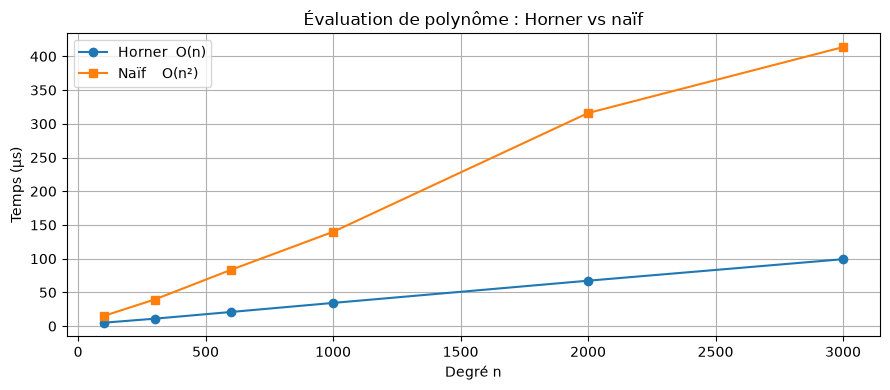

In [13]:
# NOTE : cette cellule nécessite que polynome_evaluer et polynome_evaluer_naif
# soient correctement implémentées (Partie 2.3)

def mesurer(f, *args, rep=5):
    t = timeit.Timer(lambda: f(*args))
    return t.timeit(number=rep) / rep

degres = [100, 300, 600, 1000, 2000, 3000]
temps_horner = []
temps_naif   = []

for d in degres:
    coeffs = [random.uniform(-1, 1) for _ in range(d + 1)]
    P = Polynome(coeffs)
    x = 0.5
    th = mesurer(P.evaluer, x)
    tn = mesurer(P.evaluer_naif, x)
    temps_horner.append(th)
    temps_naif.append(tn)
    print(f"deg={d:4d} | Horner: {th*1e6:.2f} µs | Naïf: {tn*1e6:.2f} µs")

plt.figure(figsize=(9, 4))
plt.plot(degres, [t*1e6 for t in temps_horner], 'o-', label='Horner  O(n)')
plt.plot(degres, [t*1e6 for t in temps_naif],   's-', label='Naïf    O(n²)')
plt.xlabel('Degré n')
plt.ylabel('Temps (µs)')
plt.title('Évaluation de polynôme : Horner vs naïf')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Question** : La courbe « naïf » ressemble-t-elle à une parabole ? Pourquoi ?

### 5.2 Multiplication de polynômes vs FFT

deg= 50 | Naïf: 1.662 ms | FFT: 2.333 ms
deg=100 | Naïf: 3.342 ms | FFT: 0.356 ms
deg=200 | Naïf: 12.171 ms | FFT: 0.699 ms
deg=400 | Naïf: 54.618 ms | FFT: 1.366 ms
deg=800 | Naïf: 212.813 ms | FFT: 1.985 ms


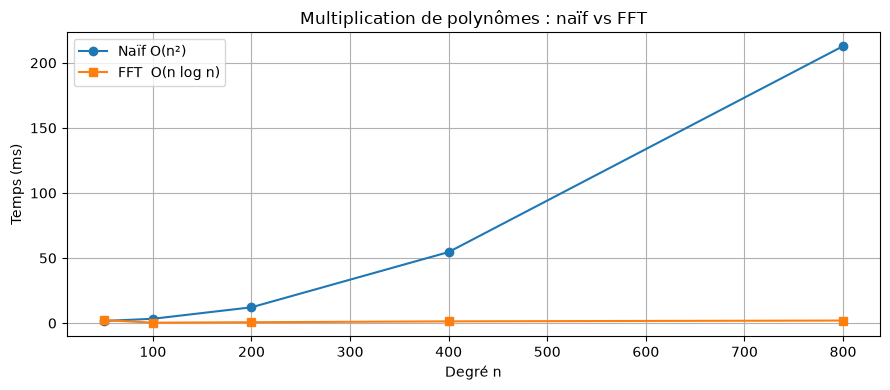

In [14]:
import numpy as np

def mul_fft(P, Q):
    """
    Multiplication de polynômes via FFT.
    Utilise numpy.fft : O(n log n) contre O(n^2) pour la méthode naïve.

    Principe :
      1. Évaluer P et Q en 2n racines de l'unité (FFT)
      2. Multiplier point par point
      3. Interpoler (IFFT)

    Référence : CLRS, chapitre 30.
    """
    n = P.degre + Q.degre + 1
    taille = 1
    while taille < n:
        taille *= 2
    fp = np.fft.fft(P.coeffs, taille)
    fq = np.fft.fft(Q.coeffs, taille)
    produit = np.fft.ifft(fp * fq).real
    coeffs_entiers = [round(c) for c in produit[:n]]
    return Polynome(coeffs_entiers)

degres_mul = [50, 100, 200, 400, 800]
temps_naif_mul = []
temps_fft_mul  = []

for d in degres_mul:
    coeffs = [random.randint(-5, 5) for _ in range(d + 1)]
    P = Polynome(coeffs)
    Q = Polynome(coeffs[:])
    tn = mesurer(P.__mul__, Q, rep=3)
    tf = mesurer(mul_fft, P, Q, rep=3)
    temps_naif_mul.append(tn)
    temps_fft_mul.append(tf)
    print(f"deg={d:3d} | Naïf: {tn*1e3:.3f} ms | FFT: {tf*1e3:.3f} ms")

plt.figure(figsize=(9, 4))
plt.plot(degres_mul, [t*1e3 for t in temps_naif_mul], 'o-', label='Naïf O(n²)')
plt.plot(degres_mul, [t*1e3 for t in temps_fft_mul],  's-', label='FFT  O(n log n)')
plt.xlabel('Degré n')
plt.ylabel('Temps (ms)')
plt.title('Multiplication de polynômes : naïf vs FFT')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 5.3 Élimination de Gauss : complexité $\mathcal{O}(n^3)$

n= 10 : 0.157 ms
n= 20 : 0.798 ms
n= 40 : 6.164 ms
n= 80 : 36.409 ms
n=150 : 238.616 ms


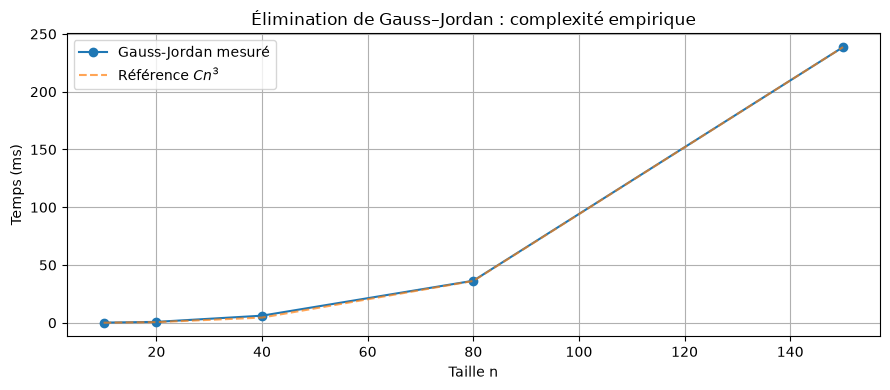

In [15]:
# NOTE : nécessite gauss_jordan implémenté

tailles = [10, 20, 40, 80, 150]
temps_gauss = []

for n in tailles:
    A = Matrice.aleatoire(n, n)
    # On ajoute n*I pour s'assurer d'une bonne conditionnabilité
    for i in range(n):
        A.data[i][i] += n
    b = [random.uniform(-10, 10) for _ in range(n)]
    t = mesurer(A.gauss_jordan, b, rep=3)
    temps_gauss.append(t)
    print(f"n={n:3d} : {t*1e3:.3f} ms")

# Ajustement : temps ≈ C * n^3
n3 = [n**3 for n in tailles]
C = temps_gauss[-1] / n3[-1]
ref_cubique = [C * v for v in n3]

plt.figure(figsize=(9, 4))
plt.plot(tailles, [t*1e3 for t in temps_gauss],    'o-', label='Gauss-Jordan mesuré')
plt.plot(tailles, [t*1e3 for t in ref_cubique],    '--', label='Référence $Cn^3$', alpha=0.7)
plt.xlabel('Taille n')
plt.ylabel('Temps (ms)')
plt.title('Élimination de Gauss–Jordan : complexité empirique')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

n= 10 : 0.191 ms
n= 20 : 0.679 ms
n= 40 : 5.615 ms
n= 80 : 36.449 ms
n=150 : 231.279 ms


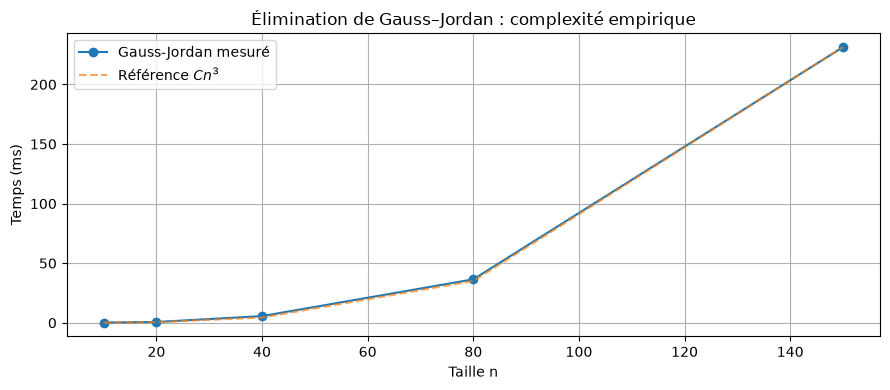

In [16]:
# NOTE : nécessite gauss_jordan implémenté

tailles = [10, 20, 40, 80, 150]
temps_gauss = []

for n in tailles:
    A = Matrice.aleatoire(n, n)
    # On ajoute n*I pour s'assurer d'une bonne conditionnabilité
    for i in range(n):
        A.data[i][i] += n
    b = [random.uniform(-10, 10) for _ in range(n)]
    t = mesurer(A.gauss_jordan, b, rep=3)
    temps_gauss.append(t)
    print(f"n={n:3d} : {t*1e3:.3f} ms")

# Ajustement : temps ≈ C * n^3
n3 = [n**3 for n in tailles]
C = temps_gauss[-1] / n3[-1]
ref_cubique = [C * v for v in n3]

plt.figure(figsize=(9, 4))
plt.plot(tailles, [t*1e3 for t in temps_gauss],    'o-', label='Gauss-Jordan mesuré')
plt.plot(tailles, [t*1e3 for t in ref_cubique],    '--', label='Référence $Cn^3$', alpha=0.7)
plt.xlabel('Taille n')
plt.ylabel('Temps (ms)')
plt.title('Élimination de Gauss–Jordan : complexité empirique')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

---
## Partie 6 — Exercices

Traitez **au moins 3 exercices** parmi ceux proposés. Les 2 premiers sont guidés (stubs fournis).

### Exercice 1 — Classe `Complexe` (guidé)

Implémentez la classe `Complexe` représentant $z = a + ib$ avec surcharge complète des opérateurs.  
Vérifiez que $|z \cdot w| = |z| \cdot |w|$.

In [17]:
class Complexe:
    def __init__(self, re, im=0):
        self.re = re
        self.im = im

    def __add__(self, other):
        # TODO
        return Complexe(self.re + other.re,self.im + other.im)

    def __mul__(self, other):
        # TODO : (a+ib)(c+id) = (ac-bd) + i(ad+bc)
        return Complexe(self.re * other.re - self.im * other.im, self.re * other.im + self.im * other.re)

    def conjugue(self):
        # TODO
        return Complexe(self.re,-self.im)

    def module(self):
        # TODO : sqrt(re^2 + im^2)
        return pow(self.re**2+ self.im**2,0.5)
        raise NotImplementedError

    def __str__(self):
        signe = '+' if self.im >= 0 else '-'
        return f"{self.re} {signe} {abs(self.im)}i"

    def __repr__(self):
        return f"Complexe({self.re}, {self.im})"

# Tests automatiques
z1, z2 = Complexe(3, 4), Complexe(1, -2)
assert abs(z1.module() - 5.0) < 1e-10, "Module de 3+4i"
assert abs((z1 * z2).module() - z1.module() * z2.module()) < 1e-10, "|zw| = |z||w|"
print(f"z1 = {z1},  z2 = {z2}")
print(f"z1 * z2 = {z1 * z2}")
print("Exercice 1 OK")

z1 = 3 + 4i,  z2 = 1 - 2i
z1 * z2 = 11 - 2i
Exercice 1 OK


Exercice 2 — Interpolation de Lagrange (guidé)

Étant donnés $n+1$ points $(x_0, y_0), \ldots, (x_n, y_n)$, le polynôme d'interpolation est :
$$L(X) = \sum_{i=0}^{n} y_i \prod_{j \neq i} \frac{X - x_j}{x_i - x_j}$$

Testez sur les points $(0,0), (1,1), (2,4)$ — résultat attendu : $X^2$.

In [18]:
def lagrange(xs, ys):
    """
    Calcule le polynôme d'interpolation de Lagrange.

    xs : liste de n+1 abscisses distinctes
    ys : liste de n+1 ordonnées
    Retourne : objet Polynome de degré <= n

    Complexité : O(n^2) en nombre de multiplications de polynômes.
    """
    n = len(xs)
    resultat = Polynome([0])
    for i in range(n):
        # Calculer le polynôme de base L_i
        # L_i = produit sur j != i de (X - x_j) / (x_i - x_j)
        Li = Polynome([1])
        for j in range(n):
            if j != i:
                facteur = Polynome([-xs[j], 1])       # (X - x_j)
                denominateur = xs[i] - xs[j]
                Li = Li * facteur * (1.0 / denominateur)
        resultat = resultat + ys[i] * Li
    return resultat

# Tests
P = lagrange([0, 1, 2], [0, 1, 4])
print(f"Interpolation : {P}")  # doit être X^2
assert abs(P.evaluer(1.5) - 1.5**2) < 1e-9
print("Exercice 2 OK")


Interpolation : X^2
Exercice 2 OK


### Exercice 3 — Vérification des axiomes d'anneau (ouvert)

In [19]:
def verifier_anneau(P, Q, R):
    """
    Vérifie les axiomes d'anneau pour des objets Polynome.

    - Commutativité de + : P + Q = Q + P
    - Associativité de * : (P*Q)*R = P*(Q*R)
    - Distributivité   : P*(Q+R) = P*Q + P*R
    - Élément neutre de + : P + zero = P
    - Élément neutre de * : P * un = P

    Retourne True si tous les axiomes sont vérifiés, False sinon.
    """
    un = Polynome([1])

    commutativite_add = (P + Q) == (Q + P)
    associativite_mul = ((P * Q) * R) == (P * (Q * R))
    distributivite = (P * (Q + R)) == (P * Q + P * R)
    neutre_add = (P + P.zero) == P
    neutre_mul = (P * un) == P

    if not commutativite_add:
        print("Échec : commutativité de l'addition")
    if not associativite_mul:
        print("Échec : associativité de la multiplication")
    if not distributivite:
        print("Échec : distributivité")
    if not neutre_add:
        print("Échec : élément neutre de l'addition")
    if not neutre_mul:
        print("Échec : élément neutre de la multiplication")

    return commutativite_add and associativite_mul and distributivite and neutre_add and neutre_mul

P = Polynome([1, -1, 2])
Q = Polynome([3, 0, -1, 1])
R = Polynome([2, 1])
print(verifier_anneau(P, Q, R))


True


### Exercice 4 — Décomposition LU (ouvert)

Implémentez la décomposition $A = LU$ (sans pivot) comme méthode de la classe `Matrice`.  
Exprimez ensuite la résolution de $Ax = b$ en deux substitutions :  
$Ly = b$ (substitution avant) puis $Ux = y$ (substitution arrière).

In [25]:
def matrice_decomposition_LU(self):
    """
    Décomposition A = LU sans pivot.
    Retourne (L, U) où L est triangulaire inférieure (diagonale = 1)
    et U est triangulaire supérieure.
    Complexité : O(n^3).

    Référence : Trefethen & Bau, Numerical Linear Algebra, Lecture 20.
    """
    assert self.m == self.n, "La décomposition LU nécessite une matrice carrée"
    n = self.n
    U = [lig[:] for lig in self.data]  # On initialise U avec une copie de la matrice A  
    L = [[1.0 if i == j else 0.0 for j in range(n)] for i in range(n)]   # On initialise L comme une matrice identité

    for col in range(n):
        pivot = U[col][col]    # Parcours des colonnes pour effectuer l'élimination de Gauss

        assert abs(pivot) > 1e-12, "Pivot nul : décomposition LU sans pivot impossible"  
        # Vérification que le pivot n'est pas nul
        for r in range(col + 1, n):
            facteur = U[r][col] / pivot       # Élimination des éléments sous le pivot
            L[r][col] = facteur   # On conserve les multiplicateurs dans L
            for k in range(col, n):  
                U[r][k] -= facteur * U[col][k]              # Mise à jour de U


    return Matrice(L), Matrice(U)

def substitution_avant(L, b):
    """Résout Ly = b, L triangulaire inférieure. O(n^2)."""
    n = L.n
    y = [0.0] * n
    for i in range(n):      # Calcul de y de haut en bas

        y[i] = (b[i] - sum(L.data[i][j] * y[j] for j in range(i))) / L.data[i][i]
    return y

def substitution_arriere(U, b):
    """Résout Ux = b, U triangulaire supérieure. O(n^2)."""
    n = U.n
    x = [0.0] * n   # Calcul de x de bas en haut
    for i in reversed(range(n)):
        x[i] = (b[i] - sum(U.data[i][j] * x[j] for j in range(i + 1, n))) / U.data[i][i]
    return x

Matrice.decomposition_LU = matrice_decomposition_LU

# Tests
A = Matrice([[2, 1, 1], [4, 3, 3], [8, 7, 9]]) 
# Exemple de matrice
L, U = A.decomposition_LU()
print("L ="); print(L)
print("U ="); print(U)
print("LU ="); print(L * U)   # doit redonner A  verification 

# Résolution de Ax = b :
# 1) Ly = b
# 2) Ux = y
b = [4.0, 10.0, 24.0]
y = substitution_avant(L, b)
x = substitution_arriere(U, y)
print(f"Solution x = {[round(v, 6) for v in x]}")

x_reference = A.gauss_jordan(b)  # Comparaison avec Gauss-Jordan
assert all(abs(a - c) < 1e-9 for a, c in zip(x, x_reference)), "LU != Gauss-Jordan"
print("Exercice 4 OK")


L =
| 1  0  0 |
| 2  1  0 |
| 4  3  1 |
U =
| 2  1  1 |
| 0  1  1 |
| 0  0  2 |
LU =
| 2  1  1 |
| 4  3  3 |
| 8  7  9 |
Solution x = [1.0, 1.0, 1.0]
Exercice 4 OK


### Exercice 5 — Méthode de Jacobi (ouvert)

L'itération de Jacobi met à jour :
$$x_i^{(k+1)} = \frac{1}{a_{ii}}\left(b_i - \sum_{j \neq i} a_{ij} x_j^{(k)}\right)$$

Convergente si $A$ est à diagonale strictement dominante.

In [22]:
def matrice_jacobi(self, b, tol=1e-8, max_iter=1000):
    """
    Résolution de Ax = b par itération de Jacobi.
    Retourne (x, nb_iterations).
    Complexité par itération : O(n^2).
    """
    n = self.n
    x = [0.0] * n # Choisit le vecteur initial :
    # x^(0) = (0, 0, ..., 0).
    for iteration in range(1, max_iter + 1):
        x_nouveau = [0.0] * n   
        for i in range(n):
            somme = sum(self.data[i][j] * x[j] for j in range(n) if j != i)  
            # Calcule :
            # somme = Σ(j ≠ i) a_ij * x_j
            # On exclut j = i car on ne prend pas le terme diagonal a_ii*x_i.
            x_nouveau[i] = (b[i] - somme) / self.data[i][i]  # Calcule la nouvelle valeur x_i.
            # Formule de Jacobi :
            # x_i^(k+1)= [b_i - Σ(j≠i) a_ij*x_j^(k)] / a_ii
            # self.data[i][i] représente a_ii.

            
        # Critère d'arrêt : norme infinie de la différence
        erreur = max(abs(x_nouveau[i] - x[i]) for i in range(n))   
        # Calcule l'erreur entre l'ancien vecteur et le nouveau vecteur.
        # erreur = max_i |x_i^(k+1) - x_i^(k)|

        x = x_nouveau
        if erreur < tol:  
            return x, iteration
    return x, max_iter

Matrice.jacobi = matrice_jacobi# Ajoute la fonction matrice_jacobi à la classe Matrice.
# On peut donc ensuite utiliser : A.jacobi(b)


# Tester sur une matrice diagonalement dominante

n = 5
# On choisit une matrice de dimension 5x
# Tester sur une matrice diagonalement dominante
n = 5
A = Matrice.identite(n) * 10
for i in range(n):
    for j in range(n):
        if i != j:
            A.data[i][j] = random.uniform(-1, 1)
b = [random.uniform(-5, 5) for _ in range(n)]
x_jacobi, iters = A.jacobi(b)
x_gauss = A.gauss_jordan(b)
print(f"Jacobi ({iters} it.) : {[round(v,6) for v in x_jacobi]}")
print(f"Gauss  (exact)    : {[round(v,6) for v in x_gauss]}")
assert all(abs(a - c) < 1e-6 for a, c in zip(x_jacobi, x_gauss)), "Jacobi != Gauss"
print("Exercice 5 OK")


Jacobi (9 it.) : [0.062958, 0.360423, 0.024051, -0.053392, -0.172485]
Gauss  (exact)    : [0.062958, 0.360423, 0.024051, -0.053392, -0.172485]
Exercice 5 OK


---
## Partie 7 — Problèmes Ouverts

Ces problèmes sont **optionnels** mais font partie des livrables bonus (+2 points chacun).

### Problème 1 — Corps de Galois $\mathbb{F}_2[X]/(P(X))$ (AES)

Le standard AES utilise le corps $\mathrm{GF}(2^8) = \mathbb{F}_2[X]/(X^8 + X^4 + X^3 + X + 1)$.  

**Objectif** : implémenter une classe `PolyMod` représentant les éléments de ce corps avec :
- Addition = XOR des coefficients modulo 2
- Multiplication modulo $P(X) = X^8 + X^4 + X^3 + X + 1$
- Inversion via l'algorithme d'Euclide étendu pour polynômes

> Référence : CLRS §31.7 ; FIPS 197 (standard AES, NIST).

In [23]:
# Problème 1 : Corps GF(2^8)
# Modulaire AES : P(X) = X^8 + X^4 + X^3 + X + 1
# Représentation : entier de 8 bits (bit i = coefficient de X^i)

# TODO : implémenter la classe PolyMod et les opérations
pass

### Problème 2 — Classe `MatriceCreuse` (Sparse Matrix)

Une matrice creuse stocke uniquement les entrées non nulles.  
**Objectif** : classe `MatriceCreuse` héritant de `StructureAlgebrique`, avec stockage `dict {(i,j): val}`,
opérations `+`, `*`, produit matrice-vecteur, et comparaison d'utilisation mémoire.

> Référence : Strang, *CSE*, chapter 7.

In [24]:
# Problème 2 : MatriceCreuse
# TODO
pass

### Problème 3 — Multiplication rapide par FFT

La multiplication naïve coûte $\mathcal{O}(n^2)$. Via FFT : $\mathcal{O}(n \log n)$.

**Objectif** : implémenter `mul_fft_entiers` pour des polynômes **à coefficients entiers**,
comparer avec la multiplication naïve pour des degrés allant jusqu'à $10^5$,  
puis expliquer pourquoi l'arithmétique flottante est problématique pour les grands entiers.

> Référence : CLRS, chapitre 30.

In [72]:
# Problème 3 : FFT pour entiers
# TODO
pass



---
## Partie 8 — Livrable

### Checklist

Avant de rendre votre notebook, vérifiez :

- [ ] Toutes les cellules s'exécutent sans erreur (sauf celles avec `raise NotImplementedError` non traité)
- [ ] Les stubs de la **Partie 2** (Polynome) sont tous implémentés
- [ ] Les stubs de la **Partie 3** (Matrice) sont tous implémentés
- [ ] Les graphiques de la **Partie 5** sont générés et commentés
- [ ] Au moins **3 exercices** de la Partie 6 sont traités
- [ ] Les tests Lean 4 de la Partie 4 sont dans un fichier `seance3.lean` dans le dépôt

### Rendu sur GitHub

```bash
git add seance3.ipynb seance3.lean
git commit -m "Séance 3 : POO avancée, Polynômes et Matrices"
git push
```

### Critères d'évaluation (10 points)

| Critère | Points |
|---------|--------|
| Correction et complétude de `Polynome` (add, mul, Horner, dérivée, pgcd) | 3 |
| Correction et complétude de `Matrice` (gauss_jordan, déterminant) | 3 |
| Exercices Lean 4 (au moins Exo 4.1 et 4.2) | 2 |
| Graphiques complexité commentés + Git propre | 2 |

**Bonus** : +2 pts par Problème ouvert complet et documenté.